LOGISTIC REGRESSION
Accuracy: 0.7295954577714692
ROC AUC: 0.8378464956470071
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.49      0.77      0.60       374

    accuracy                           0.73      1409
   macro avg       0.70      0.74      0.70      1409
weighted avg       0.79      0.73      0.74      1409

RANDOM FOREST
Accuracy: 0.7714691270404542
ROC AUC: 0.8394288150042626
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

XGBOOST
Accuracy: 0.794180269694819
ROC AUC: 0.8343292257614507
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64  

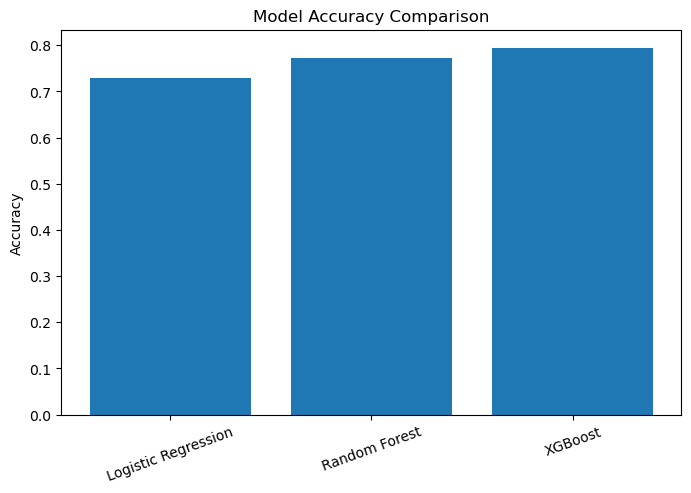

✅ Best model and scaler saved successfully


In [1]:
# =========================================================
# CUSTOMER CHURN PREDICTION - ADVANCED HIGH ACCURACY MODEL
# =========================================================

# ---------------- IMPORT LIBRARIES ----------------
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Try XGBoost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

# ---------------- LOAD DATA ----------------
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# ---------------- CLEANING ----------------
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# ---------------- ENCODE CATEGORICAL ----------------
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# ---------------- FEATURE ENGINEERING ----------------
df['AvgChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# ---------------- SELECT IMPORTANT FEATURES ----------------
features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'PaymentMethod',
    'InternetService',
    'OnlineSecurity',
    'TechSupport',
    'AvgChargesPerMonth'
]

X = df[features]
y = df['Churn']

# ---------------- SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------- SCALE ----------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 1) LOGISTIC REGRESSION (BALANCED)
# =========================================================
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("ROC AUC:", roc_auc_score(y_test, lr_prob))
print(classification_report(y_test, lr_pred))

# =========================================================
# 2) RANDOM FOREST
# =========================================================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("="*50)
print("RANDOM FOREST")
print("="*50)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred))

# =========================================================
# 3) XGBOOST
# =========================================================
if xgb_available:
    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    )

    xgb.fit(X_train, y_train)

    xgb_pred = xgb.predict(X_test)
    xgb_prob = xgb.predict_proba(X_test)[:, 1]

    print("="*50)
    print("XGBOOST")
    print("="*50)
    print("Accuracy:", accuracy_score(y_test, xgb_pred))
    print("ROC AUC:", roc_auc_score(y_test, xgb_prob))
    print(classification_report(y_test, xgb_pred))

# =========================================================
# MODEL COMPARISON
# =========================================================
scores = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Random Forest": accuracy_score(y_test, rf_pred)
}

if xgb_available:
    scores["XGBoost"] = accuracy_score(y_test, xgb_pred)

print("\nMODEL COMPARISON")
print(scores)

plt.figure(figsize=(8,5))
plt.bar(scores.keys(), scores.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

# =========================================================
# SAVE BEST MODEL (RANDOM FOREST)
# =========================================================
best_model = rf

pickle.dump(best_model, open("customer_churn_advanced_model.pkl", "wb"))
pickle.dump(scaler, open("advanced_scaler.pkl", "wb"))

print("✅ Best model and scaler saved successfully")

In [2]:
# ================= ML PREDICTIONS FOR POWER BI =================

# Add prediction column
df['Predicted_Churn'] = best_model.predict(X)

# Add churn probability
df['Churn_Probability'] = best_model.predict_proba(X)[:, 1]

# Save final ML dataset for Power BI
df.to_csv("powerbi_churn_ml_data.csv", index=False)

print("✅ ML prediction CSV exported successfully")

✅ ML prediction CSV exported successfully


In [3]:
# Random Forest feature importance export
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.to_csv("feature_importance.csv", index=False)

print("✅ feature_importance.csv exported successfully")

✅ feature_importance.csv exported successfully
